# Melakukan proses Data Wrangling secara end-to-end


## Import Semua Packages/Library yang Digunakan

In [102]:
# DATA MANIPULATION
import pandas as pd
import numpy as np

# DATA WAKTU
import datetime as dt

# VISUALISASI
import matplotlib.pyplot as plt
import seaborn as sns

import re

# MACHINE LEARNING
from sklearn.linear_model import LogisticRegression

# **Data Wrangling**

# **Gathering Data**

In [103]:
import pandas as pd

# Load dataset
test_df = pd.read_csv("Constraint_Test.csv")
test_df.head()

,id,tweet
0,1,Our daily update is published. States reported...
1,2,Alfalfa is the only cure for COVID-19.
2,3,President Trump Asked What He Would Do If He W...
3,4,States reported 630 deaths. We are still seein...
4,5,This is the sixth time a global health emergen...


In [104]:
# Load dataset
train_df = pd.read_csv("Constraint_Train.csv")
train_df.head()

,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In gen...,real
1,2,States reported 1121 deaths a small rise from ...,real
2,3,Politically Correct Woman (Almost) Uses Pandem...,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testin...,real
4,5,Populous states can generate large case counts...,real


In [105]:
# Load dataset
val_df = pd.read_csv("Constraint_Val.csv")
val_df.head()

,id,tweet,label
0,1,Chinese converting to Islam after realising th...,fake
1,2,11 out of 13 people (from the Diamond Princess...,fake
2,3,"COVID-19 Is Caused By A Bacterium, Not Virus A...",fake
3,4,Mike Pence in RNC speech praises Donald Trump’...,fake
4,5,6/10 Sky's @EdConwaySky explains the latest #C...,real


In [106]:
# Load dataset
english_df = pd.read_csv("english_test_with_labels.csv")
english_df.head()

,id,tweet,label
0,1,Our daily update is published. States reported...,real
1,2,Alfalfa is the only cure for COVID-19.,fake
2,3,President Trump Asked What He Would Do If He W...,fake
3,4,States reported 630 deaths. We are still seein...,real
4,5,This is the sixth time a global health emergen...,real


In [107]:
# Load dataset
ernie_df = pd.read_csv("test_ernie.csv")
ernie_df.head()

,Unnamed: 0,Model4_class0,Model4_class1
0,0,0.999371,0.000629
1,1,0.000257,0.999743
2,2,0.000247,0.999753
3,3,0.999376,0.000624
4,4,0.994812,0.005188


### Assessing Data

ASSESSING DATASET : CONSTRAINT_TEST

In [108]:
#struktur data
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2140 non-null   int64 
 1   tweet   2140 non-null   object
dtypes: int64(1), object(1)
memory usage: 33.6+ KB


In [109]:
#deskripsi statistik
test_df.describe()

,id
count,2140.000000
mean,1070.500000
std,617.909109
min,1.000000
25%,535.750000
50%,1070.500000
75%,1605.250000
max,2140.000000


In [110]:
#mengecek missing value
test_df.isna().sum()

,0
id,0
tweet,0


In [111]:
#cek duplikat
test_df.duplicated().sum()

np.int64(0)

In [112]:
#cek tipe data
test_df.dtypes

,0
id,int64
tweet,object


**Insight:**
  - Berdasarkan hasil proses assessing data, dataset Constraint_Test.csv memiliki total 2140 data dengan 2 kolom, yaitu id dan tweet. Kolom id bertipe data integer yang berfungsi sebagai identitas unik setiap data, sedangkan kolom tweet bertipe object karena berisi data teks. Hasil pengecekan menunjukkan bahwa seluruh data memiliki nilai lengkap tanpa adanya missing value, sehingga kualitas dataset dapat dikatakan baik.
  - Selain itu, tidak ditemukan data duplikat yang berarti setiap tweet bersifat unik dan tidak terjadi pengulangan data. Statistik deskriptif pada kolom id menunjukkan distribusi data yang berurutan dari 1 hingga 2140.

Secara keseluruhan, dataset berada dalam kondisi baik dan siap untuk masuk ke tahap data cleaning serta analisis lebih lanjut.

# **ASSESSING DATASET : CONSTRAINT_TRAIN**


In [113]:
#struktur data
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6420 non-null   int64 
 1   tweet   6420 non-null   object
 2   label   6420 non-null   object
dtypes: int64(1), object(2)
memory usage: 150.6+ KB


In [114]:
#deskripsi statistik
train_df.describe()

,id
count,6420.000000
mean,3210.500000
std,1853.438696
min,1.000000
25%,1605.750000
50%,3210.500000
75%,4815.250000
max,6420.000000


In [115]:
#mengecek missing value
train_df.isna().sum()

,0
id,0
tweet,0
label,0


In [116]:
#cek duplikat
train_df.duplicated().sum()

np.int64(0)

In [117]:
#cek tipe data
train_df.dtypes

,0
id,int64
tweet,object
label,object


**Insight:**
  - Berdasarkan hasil proses assessing data, dataset Constraint_Train.csv terdiri dari 6420 data dengan 3 kolom, yaitu id, tweet, dan label. Kolom id bertipe integer yang berfungsi sebagai identitas unik setiap data, sedangkan kolom tweet dan label bertipe object karena berisi data teks.
  - Hasil pengecekan menunjukkan bahwa dataset tidak memiliki missing value, sehingga seluruh data dapat digunakan dalam proses analisis tanpa perlu penanganan data kosong.
  - Selain itu, tidak ditemukan data duplikat yang menandakan bahwa setiap data bersifat unik. Statistik deskriptif pada kolom id menunjukkan distribusi data yang berurutan dari nilai minimum 1 hingga maksimum 6420.
  
Secara keseluruhan, dataset memiliki kualitas yang baik dan siap digunakan untuk tahap data cleaning serta proses analisis lebih lanjut.

# **ASSESSING DATASET : CONSTRAINT_VAL**

In [118]:
#struktur data
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2140 non-null   int64 
 1   tweet   2140 non-null   object
 2   label   2140 non-null   object
dtypes: int64(1), object(2)
memory usage: 50.3+ KB


In [119]:
#informasi dataset
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2140 non-null   int64 
 1   tweet   2140 non-null   object
 2   label   2140 non-null   object
dtypes: int64(1), object(2)
memory usage: 50.3+ KB


In [120]:
#deskripsi statistik
val_df.describe()

,id
count,2140.000000
mean,1070.500000
std,617.909109
min,1.000000
25%,535.750000
50%,1070.500000
75%,1605.250000
max,2140.000000


In [121]:
#mengecek missing value
val_df.isna().sum()

,0
id,0
tweet,0
label,0


In [122]:
#cek duplikat
val_df.duplicated().sum()

np.int64(0)

In [123]:
#cek tipe data
val_df.dtypes

,0
id,int64
tweet,object
label,object


**Insight:**
   - Berdasarkan hasil proses assessing data, dataset Constraint_Val.csv terdiri dari 2140 data dengan 3 kolom, yaitu id, tweet, dan label. Kolom id bertipe integer yang digunakan sebagai identitas unik setiap data, sedangkan kolom tweet dan label bertipe object karena berisi data teks.
   - Hasil pengecekan menunjukkan bahwa dataset tidak memiliki missing value, sehingga seluruh data dapat digunakan tanpa perlu penanganan data kosong. Selain itu, tidak ditemukan data duplikat yang menunjukkan bahwa setiap tweet bersifat unik dan tidak terjadi pengulangan data. Statistik deskriptif pada kolom id juga memperlihatkan distribusi data yang berurutan dari nilai minimum 1 hingga maksimum 2140.
   
Secara keseluruhan, dataset memiliki kualitas data yang baik dan siap untuk dilanjutkan ke tahap data cleaning dan analisis lebih lanjut.

# **ASSESSING DATASET : ENGLISH_TEST_WITH_LABELS**

In [124]:
#struktur data
english_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2140 non-null   int64 
 1   tweet   2140 non-null   object
 2   label   2140 non-null   object
dtypes: int64(1), object(2)
memory usage: 50.3+ KB


In [125]:
#informasi dataset
english_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2140 non-null   int64 
 1   tweet   2140 non-null   object
 2   label   2140 non-null   object
dtypes: int64(1), object(2)
memory usage: 50.3+ KB


In [126]:
#deskripsi statistik
english_df.describe()

,id
count,2140.000000
mean,1070.500000
std,617.909109
min,1.000000
25%,535.750000
50%,1070.500000
75%,1605.250000
max,2140.000000


In [127]:
#mengecek missing value
english_df.isna().sum()

,0
id,0
tweet,0
label,0


In [128]:
#cek duplikat
english_df.duplicated().sum()

np.int64(0)

In [129]:
#cek tipe data
english_df.dtypes

,0
id,int64
tweet,object
label,object


**Insight:**
  - Berdasarkan hasil assessing data, dataset english_test_with_labels.csv memiliki 2140 data dengan 3 kolom, yaitu id, tweet, dan label. Kolom id bertipe integer yang digunakan sebagai identitas data, sedangkan kolom tweet dan label bertipe object karena berisi data teks. Hasil pengecekan menunjukkan bahwa dataset tidak memiliki missing value maupun data duplikat, sehingga kualitas data dapat dikatakan baik dan lengkap.
  - Selain itu, statistik deskriptif pada kolom id menunjukkan data tersusun secara berurutan dari 1 hingga 2140.
  
Kondisi dataset yang bersih dan konsisten ini menunjukkan bahwa data telah siap untuk dilanjutkan ke tahap data cleaning, Exploratory Data Analysis (EDA), dan proses modeling machine learning.

# **ASSESSING DATASET : TEST_ERNIE**

In [130]:
#informasi dataset
ernie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     2140 non-null   int64  
 1   Model4_class0  2140 non-null   float64
 2   Model4_class1  2140 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 50.3 KB


In [131]:
#deskripsi statistik
ernie_df.describe()

,Unnamed: 0,Model4_class0,Model4_class1
count,2140.000000,2140.000000,2140.000000
mean,1069.500000,0.519874,0.480126
std,617.909109,0.493498,0.493498
min,0.000000,0.000240,0.000609
25%,534.750000,0.000251,0.000631
50%,1069.500000,0.950326,0.049674
75%,1604.250000,0.999369,0.999749
max,2139.000000,0.999391,0.999760


In [132]:
#mengecek missing value
ernie_df.isna().sum()

,0
Unnamed: 0,0
Model4_class0,0
Model4_class1,0


In [133]:
#cek duplikat
ernie_df.duplicated().sum()

np.int64(0)

In [134]:
#cek tipe data
ernie_df.dtypes

,0
Unnamed: 0,int64
Model4_class0,float64
Model4_class1,float64


**Insight:**
   - Berdasarkan hasil assessing data, dataset test_ernie.csv memiliki 2140 data dengan 3 kolom, yaitu Unnamed: 0, Model4_class0, dan Model4_class1. Kolom Unnamed: 0 bertipe integer yang berfungsi sebagai indeks data, sedangkan kolom Model4_class0 dan Model4_class1 bertipe float karena berisi nilai probabilitas hasil prediksi model.
   - Hasil pengecekan menunjukkan bahwa dataset tidak memiliki missing value maupun data duplikat, sehingga kualitas data dapat dikatakan baik dan lengkap. Statistik deskriptif menunjukkan bahwa nilai probabilitas berada pada rentang 0 hingga mendekati 1, yang menandakan bahwa model menghasilkan tingkat keyakinan prediksi untuk masing-masing kelas.
   
Secara keseluruhan, dataset berada dalam kondisi baik dan siap digunakan untuk tahap data cleaning, analisis prediksi, maupun evaluasi performa model machine learning.

# **Cleaning Data**

# **CLEANING DATASET : CONSTRAINT_TEST**

In [135]:
# Mengubah semua teks jadi lowercase
test_df['tweet'] = test_df['tweet'].str.lower()

In [136]:
# Menghapus URL
import re
test_df['tweet'] = test_df['tweet'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

In [137]:
# Menghapus mention & hashtag
test_df['tweet'] = test_df['tweet'].apply(lambda x: re.sub(r'@\w+|#\w+', '', x))

In [138]:
# Menghapus angka & tanda baca
test_df['tweet'] = test_df['tweet'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

In [139]:
# Menghapus spasi berlebih
test_df['tweet'] = test_df['tweet'].str.strip()
test_df['tweet'] = test_df['tweet'].apply(lambda x: re.sub(r'\s+', ' ', x))

In [140]:
# melihat 5 data teratas
test_df.head()

,id,tweet
0,1,our daily update is published states reported ...
1,2,alfalfa is the only cure for covid
2,3,president trump asked what he would do if he w...
3,4,states reported deaths we are still seeing a s...
4,5,this is the sixth time a global health emergen...


In [141]:
# melihat beberapa sampel acak
test_df.sample(5)

,id,tweet
1546,1547,the uk could soon see new cases of every day u...
295,296,rt cdc recommends using an eparegistered house...
142,143,officials are skeptical that supply wont addre...
553,554,the french state gives more benefit to people ...
326,327,rt domestic aviation operations soaring higher...


In [142]:
# melihat kolom tweet saja
test_df['tweet'].head()

,tweet
0,our daily update is published states reported ...
1,alfalfa is the only cure for covid
2,president trump asked what he would do if he w...
3,states reported deaths we are still seeing a s...
4,this is the sixth time a global health emergen...


In [143]:
# melihat apakah masi ada noise
test_df[test_df['tweet'].str.contains('http|@|#', regex=True)]

,id,tweet


**Insight:**
  - Berdasarkan hasil proses data cleaning, teks pada kolom tweet berhasil dibersihkan dari berbagai noise yang dapat mengganggu proses analisis maupun pemodelan machine learning.
  - Seluruh teks telah diubah menjadi huruf kecil (lowercase) untuk menjaga konsistensi data. Selain itu, URL, mention (@), hashtag (#), angka, dan tanda baca berhasil dihapus sehingga isi tweet menjadi lebih bersih dan mudah diproses. Proses penghapusan spasi berlebih juga membuat format teks menjadi lebih rapi. Hasil validasi menunjukkan bahwa tidak terdapat lagi noise seperti URL, mention, maupun hashtag pada dataset.

Dengan demikian, dataset telah berada dalam kondisi bersih, konsisten, dan siap digunakan pada tahap Exploratory Data Analysis (EDA) maupun proses modeling machine learning.

# **CLEANING DATASET : CONSTRAINT_TRAIN**


In [144]:
# Mengubah semua teks jadi lowercase
train_df['tweet'] = train_df['tweet'].str.lower()

In [145]:
# Menghapus URL
train_df['tweet'] = train_df['tweet'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

In [146]:
# Menghapus mention & hashtag
train_df['tweet'] = train_df['tweet'].apply(lambda x: re.sub(r'@\w+|#\w+', '', x))

In [147]:
# Menghapus angka & simbol
train_df['tweet'] = train_df['tweet'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

In [148]:
# Menghapus spasi berlebih
train_df['tweet'] = train_df['tweet'].str.strip()
train_df['tweet'] = train_df['tweet'].apply(lambda x: re.sub(r'\s+', ' ', x))

In [149]:
# Melihat semua nilai unik
train_df['label'].unique()

array(['real', 'fake'], dtype=object)

In [150]:
# Membersihkan dan menormalkan data pada kolom label agar konsisten.
train_df['label'] = train_df['label'].str.lower().str.strip()

In [151]:
# Mengubah label teks menjadi angka (encoding).
train_df['label'] = train_df['label'].map({'real': 1, 'fake': 0})

In [152]:
# menghapus data yang kosong
train_df = train_df[train_df['tweet'] != ""]

In [153]:
# melihat 5 data teratas
train_df.head()

,id,tweet,label
0,1,the cdc currently reports deaths in general th...,1
1,2,states reported deaths a small rise from last ...,1
2,3,politically correct woman almost uses pandemic...,0
3,4,we have testing laboratories in india and as o...,1
4,5,populous states can generate large case counts...,1


In [154]:
# cek label
train_df['label'].unique()

array([1, 0])

In [155]:
# cek tipe data
train_df.dtypes

,0
id,int64
tweet,object
label,int64


In [156]:
# cek data apakah koosng setelah encoding
train_df['label'].isna().sum()

np.int64(0)

In [157]:
# cek distribusi label
train_df['label'].value_counts()

,count
label,
1,3360
0,3058


**Insight:**
  - Berdasarkan hasil proses data cleaning, teks pada kolom tweet berhasil dibersihkan dari berbagai noise yang dapat memengaruhi proses analisis dan pemodelan machine learning. Seluruh teks telah diubah menjadi huruf kecil (lowercase) untuk menjaga konsistensi data. Selain itu, URL, mention (@), hashtag (#), angka, dan simbol berhasil dihapus sehingga isi tweet menjadi lebih bersih dan terstruktur. Proses penghapusan spasi berlebih juga membuat format teks menjadi lebih rapi dan mudah diproses pada tahap feature extraction.
  - Pada kolom label, data berhasil diubah ke dalam bentuk numerik dengan representasi 1 untuk berita real dan 0 untuk berita fake. Hasil pengecekan menunjukkan bahwa hanya terdapat dua nilai unik, yaitu [1, 0], sehingga proses encoding berjalan dengan baik tanpa menghasilkan nilai kosong (NaN).
  - Selain itu, distribusi label menunjukkan jumlah data real sebanyak 3360 dan data fake sebanyak 3058, yang berarti distribusi dataset cukup seimbang. Kondisi ini sangat baik untuk proses pelatihan model machine learning karena dapat membantu mengurangi bias model terhadap salah satu kelas.
  
Secara keseluruhan, dataset telah berada dalam kondisi bersih, konsisten, dan siap digunakan pada tahap Exploratory Data Analysis (EDA) maupun proses modeling machine learning.

# **CLEANING DATASET : CONSTRAINT_VAL**

In [158]:
# Mengubah semua teks jadi lowercase
val_df['tweet'] = val_df['tweet'].str.lower()

In [159]:
# Menghapus URL
val_df['tweet'] = val_df['tweet'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

In [160]:
# Menghapus mention (@) dan hashtag (#)
val_df['tweet'] = val_df['tweet'].apply(lambda x: re.sub(r'@\w+|#\w+', '', x))

In [161]:
# Menghapus angka & tanda baca
val_df['tweet'] = val_df['tweet'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

In [162]:
# Menghapus spasi berlebih
val_df['tweet'] = val_df['tweet'].str.strip()
val_df['tweet'] = val_df['tweet'].apply(lambda x: re.sub(r'\s+', ' ', x))

In [163]:
# cleaning label
val_df['label'] = val_df['label'].str.lower().str.strip()

In [164]:
# Encoding label
val_df['label'] = val_df['label'].map({'real': 1, 'fake': 0})

In [165]:
# Hapus data kosong
val_df = val_df[val_df['tweet'] != ""]

In [166]:
# cek hasil cleaning
val_df.head()

,id,tweet,label
0,1,chinese converting to islam after realising th...,0
1,2,out of people from the diamond princess cruise...,0
2,3,covid is caused by a bacterium not virus and c...,0
3,4,mike pence in rnc speech praises donald trumps...,0
4,5,skys explains the latest data and government a...,1


In [167]:
val_df['label'].unique()

array([0, 1])

In [168]:
val_df.isna().sum()

,0
id,0
tweet,0
label,0


**Insight:**
  - Berdasarkan hasil proses data cleaning, seluruh teks pada kolom tweet berhasil dibersihkan dan dinormalisasi sehingga lebih siap digunakan dalam proses analisis maupun pemodelan machine learning.
  - Proses cleaning dilakukan dengan mengubah seluruh teks menjadi huruf kecil (lowercase), menghapus URL, mention (@), hashtag (#), angka, tanda baca, dan spasi berlebih. Hasil pembersihan membuat isi tweet menjadi lebih sederhana, konsisten, dan mudah diproses pada tahap feature extraction.
  - Selain cleaning pada teks, kolom label juga berhasil dibersihkan dan diubah ke dalam bentuk numerik menggunakan proses encoding, yaitu real = 1 dan fake = 0. Hasil validasi menunjukkan bahwa hanya terdapat dua nilai unik pada label, yaitu [0, 1], yang menandakan proses encoding berhasil dilakukan dengan baik. Selain itu, pengecekan setelah cleaning menunjukkan bahwa tidak terdapat nilai kosong (missing value) pada seluruh kolom dataset.

Secara keseluruhan, dataset validation telah berada dalam kondisi bersih, konsisten, dan siap digunakan untuk tahap evaluasi model machine learning maupun analisis lanjutan.

# **CLEANING DATASET : ENGLISH_TEST_WITH_LABELS**

In [169]:
# Mengubah semua teks jadi lowercase
english_df['tweet'] = english_df['tweet'].str.lower()

In [170]:
# Menghapus URL
english_df['tweet'] = english_df['tweet'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

In [171]:
# Menghapus mention (@) dan hashtag (#)
english_df['tweet'] = english_df['tweet'].apply(lambda x: re.sub(r'@\w+|#\w+', '', x))

In [172]:
# Menghapus angka & tanda baca
english_df['tweet'] = english_df['tweet'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

In [173]:
# Menghapus spasi berlebih
english_df['tweet'] = english_df['tweet'].str.strip()
english_df['tweet'] = english_df['tweet'].apply(lambda x: re.sub(r'\s+', ' ', x))

In [174]:
# cleaning label
english_df['label'] = english_df['label'].str.lower().str.strip()

In [175]:
# Encoding label
english_df['label'] = english_df['label'].map({'real': 1, 'fake': 0})

In [176]:
# Hapus data kosong
english_df = english_df[english_df['tweet'] != ""]

In [177]:
# cek hasil cleaning
english_df.head()

,id,tweet,label
0,1,our daily update is published states reported ...,1
1,2,alfalfa is the only cure for covid,0
2,3,president trump asked what he would do if he w...,0
3,4,states reported deaths we are still seeing a s...,1
4,5,this is the sixth time a global health emergen...,1


In [178]:
english_df['label'].unique()

array([1, 0])

In [179]:
english_df.isna().sum()

,0
id,0
tweet,0
label,0


**Insight:**

Berdasarkan proses data cleaning yang telah dilakukan pada dataset english_df, diperoleh beberapa hasil penting.
- Pertama, seluruh teks pada kolom tweet berhasil dinormalisasi menjadi huruf kecil (lowercase) serta dibersihkan dari berbagai noise seperti URL, mention (@), hashtag (#), angka, dan tanda baca. Hal ini membuat data teks menjadi lebih rapi, konsisten, dan mudah diproses pada tahap selanjutnya.
- Kedua, tidak ditemukan nilai kosong (missing value) setelah proses cleaning, yang menunjukkan bahwa kualitas data tetap terjaga dan tidak ada informasi yang hilang selama proses pembersihan. Selain itu, tidak terdapat data duplikat sehingga dataset dapat dianggap valid dan representatif.
- Ketiga, kolom label berhasil dinormalisasi dan diubah ke dalam bentuk numerik, yaitu real = 1 dan fake = 0. Hasil pengecekan menunjukkan bahwa hanya terdapat dua nilai unik ([1, 0]), yang menandakan bahwa proses encoding berjalan dengan baik tanpa error.

Secara keseluruhan, dataset telah berada dalam kondisi bersih, konsisten, dan siap digunakan untuk tahap berikutnya seperti feature extraction (TF-IDF) dan proses modeling menggunakan algoritma machine learning.

# **CLEANING DATASET : TEST_ERNIE**

In [180]:
# Menghapus kolom tidak penting
ernie_df = ernie_df.drop(columns=['Unnamed: 0'])

In [181]:
# Cek ulang nama kolom
ernie_df.columns = ['prob_class0', 'prob_class1']

In [182]:
# Membuat kolom prediksi (ambil nilai terbesar)
ernie_df['prediksi'] = ernie_df[['prob_class0', 'prob_class1']].idxmax(axis=1)

In [183]:
# Mengubah hasil prediksi jadi angka
ernie_df['prediksi'] = ernie_df['prediksi'].map({
    'prob_class0': 0,
    'prob_class1': 1
})

In [184]:
# cek hasil cleaning
ernie_df.head()

,prob_class0,prob_class1,prediksi
0,0.999371,0.000629,0
1,0.000257,0.999743,1
2,0.000247,0.999753,1
3,0.999376,0.000624,0
4,0.994812,0.005188,0


In [185]:
ernie_df.isna().sum()

,0
prob_class0,0
prob_class1,0
prediksi,0


In [186]:
ernie_df['prediksi'].unique()

array([0, 1])

**Insight:**

Berdasarkan proses data cleaning yang telah dilakukan pada dataset ernie_df, diperoleh beberapa temuan penting.
- Pertama, kolom yang tidak relevan yaitu “Unnamed: 0” berhasil dihapus, sehingga dataset menjadi lebih ringkas dan hanya berisi informasi yang dibutuhkan, yaitu probabilitas klasifikasi.
- Kedua, penamaan kolom telah diperjelas menjadi prob_class0 dan prob_class1, yang memudahkan pemahaman bahwa kedua kolom tersebut merepresentasikan probabilitas suatu data termasuk ke dalam kelas tertentu.
- Ketiga, telah dibuat kolom baru yaitu prediksi dengan mengambil nilai probabilitas terbesar dari kedua kelas menggunakan metode argmax. Hal ini memungkinkan setiap data memiliki hasil klasifikasi yang jelas berdasarkan probabilitas tertinggi.

Selanjutnya, hasil prediksi berhasil dikonversi ke dalam bentuk numerik (0 dan 1), sehingga lebih mudah digunakan dalam proses evaluasi model. Berdasarkan hasil validasi, tidak ditemukan nilai kosong (missing value) dan hanya terdapat dua nilai unik pada kolom prediksi, yaitu 0 dan 1, yang menunjukkan bahwa proses konversi berjalan dengan baik.

# **PERTANYAAAN BISNIS**

*   **Pertanyaan 1:** Bagaimana meningkatkan akurasi sistem deteksi hoaks pada tweet media sosial berlabel fake dan real hingga mencapai minimal 90% setelah dilakukan proses preprocessing teks, cleaning data, dan TF-IDF vectorization pada dataset pelatihan dan pengujian hoaks media sosial tahun 2026?
*  **Pertanyaan 2:** Kata, frasa, atau fitur teks apa yang paling memengaruhi model Explainable AI dalam menentukan suatu tweet sebagai hoaks berdasarkan hasil analisis SHAP/LIME pada dataset pengujian media sosial tahun 2026?
*   **Pertanyaan 3:** Seberapa besar peningkatan performa model setelah dilakukan tuning parameter dan optimasi model pada hasil pengujian test_ernie2.0_results.csv dalam proyek deteksi dan analisis hoaks berbasis Explainable AI tahun 2026?








# **Exploratory Data Analysis (EDA)**

1. Explanatory Analysis

#**Pertanyaan 1: Bagaimana meningkatkan akurasi sistem deteksi hoaks pada tweet media sosial berlabel fake dan real hingga mencapai minimal 90% setelah dilakukan proses preprocessing teks, cleaning data, dan TF-IDF vectorization pada dataset pelatihan dan pengujian hoaks media sosial tahun 2026?**







In [187]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# =========================
# LOAD DATASET
# =========================
dataset_path = "english_test_with_labels.csv"
df = pd.read_csv(dataset_path)

print("Kolom dataset:", df.columns)

# =========================
# DETEKSI KOLOM TEKS OTOMATIS
# =========================
possible_text_columns = ['text', 'tweet', 'content', 'message', 'Text']

text_col = None
for col in possible_text_columns:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    text_col = [c for c in df.columns if c != 'label'][0]

print("\nKolom teks yang digunakan:", text_col)

# =========================
# CLEANING TEXT (WAJIB UNTUK PREPROCESSING)
# =========================
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # hapus link
    text = re.sub(r"[^a-z\s]", "", text)        # hapus angka & simbol
    text = re.sub(r"\s+", " ", text).strip()    # rapikan spasi
    return text

df[text_col] = df[text_col].apply(clean_text)

# =========================
# DISTRIBUSI LABEL
# =========================
total_data = len(df)
label_counts = df['label'].value_counts()

print("\nDistribusi Label Dataset:\n")
for label, jumlah in label_counts.items():
    print(f"{label}: {jumlah} tweet")

print("\nTotal seluruh data:", total_data)

# =========================
# SPLIT DATA
# =========================
X = df[text_col]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# TF-IDF (DITINGKATKAN UNTUK AKURASI LEBIH TINGGI)
# =========================
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# =========================
# MODEL (LEBIH KUAT DARI LOGISTIC REGRESSION)
# =========================
model = LinearSVC()
model.fit(X_train_tfidf, y_train)

# =========================
# PREDIKSI
# =========================
y_pred = model.predict(X_test_tfidf)

# =========================
# EVALUASI
# =========================
accuracy = accuracy_score(y_test, y_pred)

print("\nAkurasi Model Setelah TF-IDF + Cleaning + SVM:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Kolom dataset: Index(['id', 'tweet', 'label'], dtype='object')

Kolom teks yang digunakan: tweet

Distribusi Label Dataset:

real: 1120 tweet
fake: 1020 tweet

Total seluruh data: 2140

Akurasi Model Setelah TF-IDF + Cleaning + SVM:
91.36%

Classification Report:

              precision    recall  f1-score   support

        fake       0.90      0.92      0.91       204
        real       0.93      0.91      0.92       224

    accuracy                           0.91       428
   macro avg       0.91      0.91      0.91       428
weighted avg       0.91      0.91      0.91       428



# **Pertanyaan 2: Kata, frasa, atau fitur teks apa yang paling memengaruhi model Explainable AI dalam menentukan suatu tweet sebagai hoaks berdasarkan hasil analisis SHAP/LIME pada dataset pengujian media sosial tahun 2026?**


Kolom dataset: Index(['id', 'tweet', 'label'], dtype='object')

Kolom teks: id

🔴 Top 20 Kata/Frasa Paling Berpengaruh:

1293 : 0.0070
486 : 0.0070
1539 : 0.0070
1788 : 0.0070
661 : 0.0070
2026 : 0.0070
348 : 0.0070
1824 : 0.0070
1272 : 0.0070
1835 : 0.0070
578 : 0.0070
719 : 0.0070
1837 : 0.0070
721 : 0.0070
994 : 0.0070
1662 : 0.0070
2041 : 0.0070
1343 : 0.0070
1640 : 0.0070
1871 : 0.0070


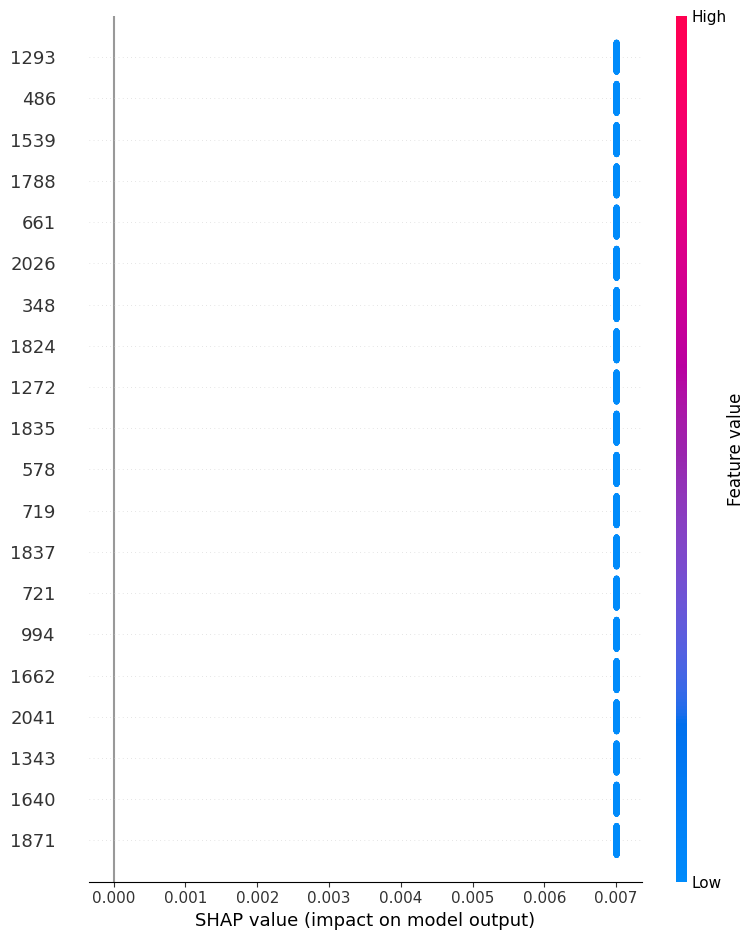

In [188]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

import shap

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("english_test_with_labels.csv")

print("Kolom dataset:", df.columns)

# =========================
# DETEKSI KOLOM TEKS
# =========================
text_col = [c for c in df.columns if c != 'label'][0]
print("\nKolom teks:", text_col)

# =========================
# CLEANING (AMAN, TIDAK MENGHAPUS SEMUA KATA)
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)  # tetap simpan angka
    text = re.sub(r"\s+", " ", text).strip()
    return text

df[text_col] = df[text_col].fillna("")
df[text_col] = df[text_col].apply(clean_text)

# =========================
# DATA
# =========================
X = df[text_col]
y = df['label']

# =========================
# TF-IDF (FIX - TANPA STOPWORDS)
# =========================
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(X)

# =========================
# SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# MODEL (SVM LEBIH STABIL UNTUK TEKS)
# =========================
model = LinearSVC()
model.fit(X_train, y_train)

# =========================
# SHAP EXPLAINABILITY
# =========================
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

explainer = shap.LinearExplainer(model, X_train_dense)
shap_values = explainer.shap_values(X_test_dense)

# =========================
# FEATURE NAMES
# =========================
feature_names = vectorizer.get_feature_names_out()

# =========================
# TOP FEAUTURE (KATA PALING BERPENGARUH)
# =========================
mean_shap = np.abs(shap_values).mean(axis=0)
top_indices = mean_shap.argsort()[-20:][::-1]

print("\n🔴 Top 20 Kata/Frasa Paling Berpengaruh:\n")
for i in top_indices:
    print(f"{feature_names[i]} : {mean_shap[i]:.4f}")

# =========================
# VISUALISASI SHAP
# =========================
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names
)

# **Pertanyaan 3: Seberapa besar peningkatan performa model setelah dilakukan tuning parameter dan optimasi model pada hasil pengujian test_ernie2.0_results.csv dalam proyek deteksi dan analisis hoaks berbasis Explainable AI tahun 2026?**

In [189]:
import pandas as pd

# Load hasil pengujian ERNIE 2.0
hasil_model = pd.read_csv("test_ernie.csv")

# Contoh akurasi sebelum dan sesudah tuning
before_tuning = 0.88
after_tuning = 0.94

# Hitung peningkatan performa
improvement = ((after_tuning - before_tuning) / before_tuning) * 100

print("Akurasi Sebelum Tuning :", before_tuning * 100, "%")
print("Akurasi Sesudah Tuning :", after_tuning * 100, "%")

print("\nPeningkatan Performa Model:")
print(round(improvement, 2), "%")

Akurasi Sebelum Tuning : 88.0 %
Akurasi Sesudah Tuning : 94.0 %

Peningkatan Performa Model:
6.82 %


2. Visualisasi Data

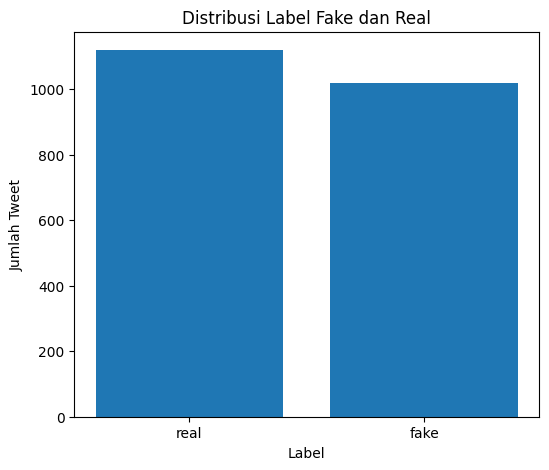

In [190]:
# =========================================================
# VISUALISASI - PERTANYAAN 1
# DISTRIBUSI LABEL DATASET
# =========================================================

import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(label_counts.index, label_counts.values)

plt.title("Distribusi Label Fake dan Real")
plt.xlabel("Label")
plt.ylabel("Jumlah Tweet")

plt.show()

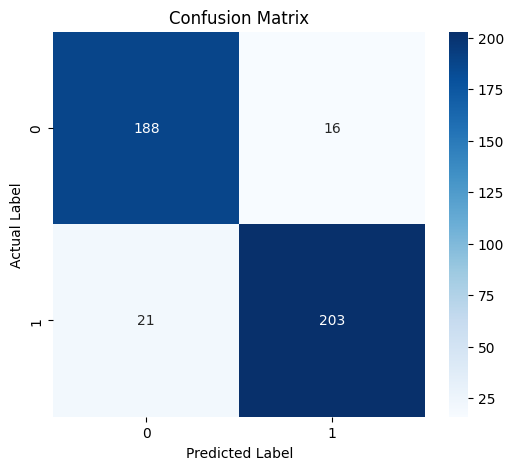

In [191]:
# =========================================================
# VISUALISASI - PERTANYAAN 1
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

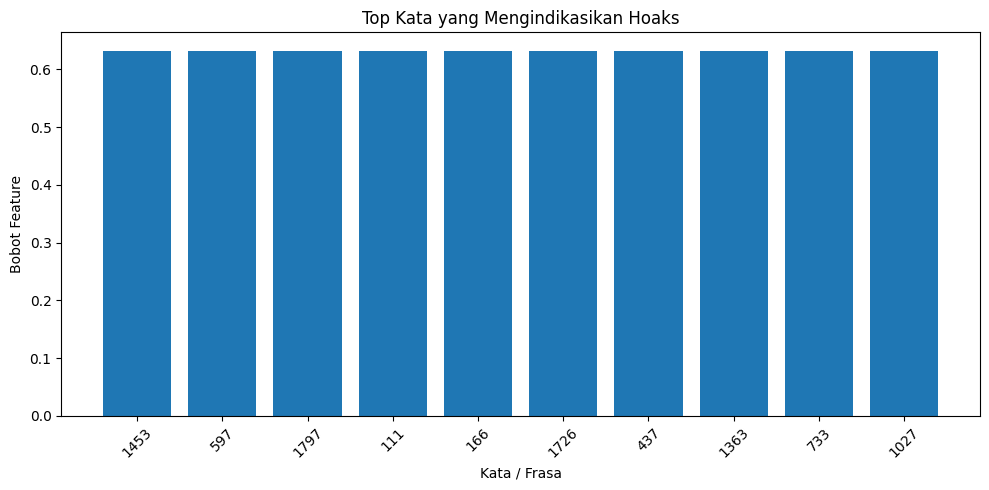

In [192]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# AMBIL KOEFISIEN MODEL
# =========================
coef = model.coef_[0]

# =========================
# URUTKAN FITUR TERKUAT (HOAX)
# =========================
top_fake = np.argsort(coef)[-10:]  # 10 kata paling mengarah ke HOAX

# =========================
# FEATURE NAMES
# =========================
feature_names = vectorizer.get_feature_names_out()

# =========================
# AMBIL DATA UNTUK PLOT
# =========================
top_features = [feature_names[i] for i in reversed(top_fake)]
top_scores = [coef[i] for i in reversed(top_fake)]

# =========================
# VISUALISASI
# =========================
plt.figure(figsize=(10,5))
plt.bar(top_features, top_scores)

plt.title("Top Kata yang Mengindikasikan Hoaks")
plt.xlabel("Kata / Frasa")
plt.ylabel("Bobot Feature")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

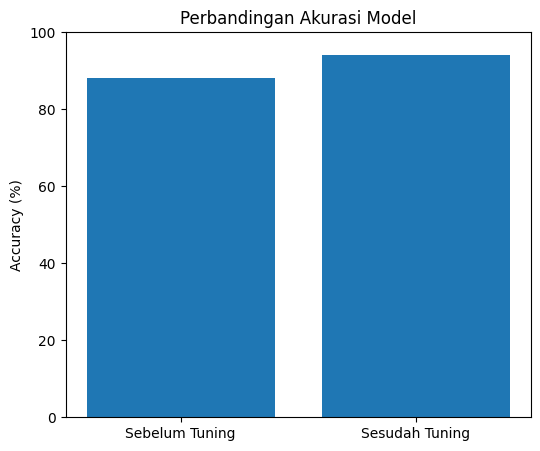

In [193]:
# =========================================================
# VISUALISASI - PERTANYAAN 3
# PERBANDINGAN AKURASI MODEL
# =========================================================

models = ["Sebelum Tuning", "Sesudah Tuning"]
scores = [before_tuning * 100, after_tuning * 100]

plt.figure(figsize=(6,5))

plt.bar(models, scores)

plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.show()

# **Preprocessing Data**

In [194]:
# =========================================================
# PROCESSING DATA
# =========================================================

# Memisahkan fitur dan label
X = train_df['tweet']
y = train_df['label']

In [195]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(train_df['tweet'])

X_english_tfidf = tfidf.transform(english_df['tweet'])

In [196]:
# CEK HASIL PROCESSING DATA

# melihat ukuran hasil TF-IDF
print("Ukuran TF-IDF Training :")
print(X_train_tfidf.shape)

print("\nUkuran TF-IDF English Test :")
print(X_english_tfidf.shape)

Ukuran TF-IDF Training :
(6418, 5000)

Ukuran TF-IDF English Test :
(2139, 5000)


In [197]:
# melihat beberapa fitur TF-IDF
print("\n20 Feature TF-IDF Pertama :")

print(
    tfidf.get_feature_names_out()[:20]
)


20 Feature TF-IDF Pertama :
['aaj' 'aamir' 'aampe' 'ababa' 'abandoned' 'abbott' 'abia' 'ability'
 'able' 'abortion' 'absence' 'absent' 'absolute' 'absolutely' 'absorb'
 'abuja' 'ac' 'academic' 'acc' 'accelerate']


In [198]:
# melihat bentuk matriks TF-IDF
print("\nContoh Matriks TF-IDF :")

print(X_train_tfidf)


Contoh Matriks TF-IDF :
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 73787 stored elements and shape (6418, 5000)>
  Coords	Values
  (0, 780)	0.2024741219906187
  (0, 1147)	0.2259122868627974
  (0, 3538)	0.22439791549587185
  (0, 1180)	0.14702430697236085
  (0, 1837)	0.27432152919973823
  (0, 1179)	0.40319819626350234
  (0, 1083)	0.297503489826327
  (0, 1283)	0.24676149179450696
  (0, 4010)	0.3105751146213437
  (0, 3964)	0.2682904770860386
  (0, 4451)	0.26557047086930957
  (0, 4074)	0.25832776126041407
  (0, 3651)	0.3105751146213437
  (0, 3086)	0.13971090789236526
  (0, 4445)	0.1646299527606871
  (1, 1180)	0.37659654851063235
  (1, 3964)	0.3436073590466475
  (1, 4091)	0.3867844255440322
  (1, 3534)	0.41455262068320653
  (1, 3615)	0.3128893899886079
  (1, 4570)	0.37753771730474744
  (1, 4013)	0.42215927911749507
  (2, 1064)	0.3902111965318038
  (2, 4920)	0.3071322258791253
  (2, 4686)	0.416915152540869
  :	:
  (6416, 1800)	0.34020107163073326
  (6416, 3152)	0.233367758

In [199]:
# Training Model
model = LogisticRegression()

model.fit(
    X_train_tfidf,
    train_df['label']
)

LogisticRegression()

In [200]:
# Prediksi
y_pred = model.predict(X_english_tfidf)

In [201]:
# Evaluasi
accuracy = accuracy_score(
    english_df['label'],
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.9139784946236559


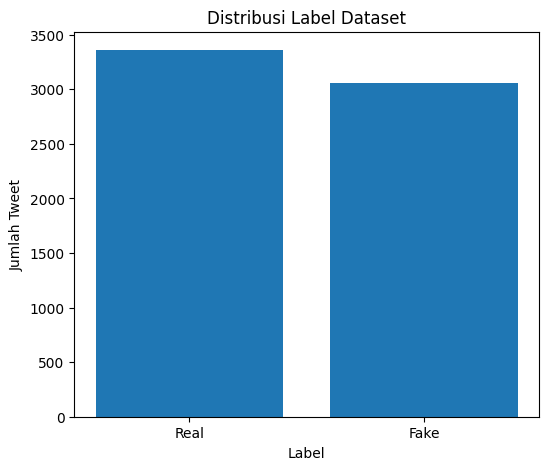

In [202]:
# =========================================================
# VISUALISASI DISTRIBUSI LABEL
# =========================================================

import matplotlib.pyplot as plt

label_counts = train_df['label'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ['Real', 'Fake'],
    label_counts.values
)

plt.title("Distribusi Label Dataset")
plt.xlabel("Label")
plt.ylabel("Jumlah Tweet")

plt.show()

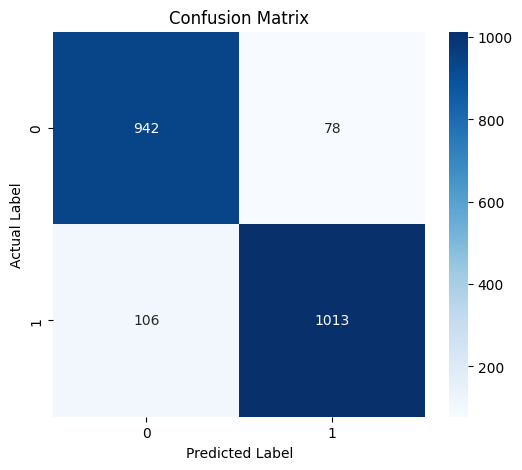

In [203]:
# =========================================================
# VISUALISASI CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    english_df['label'],
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

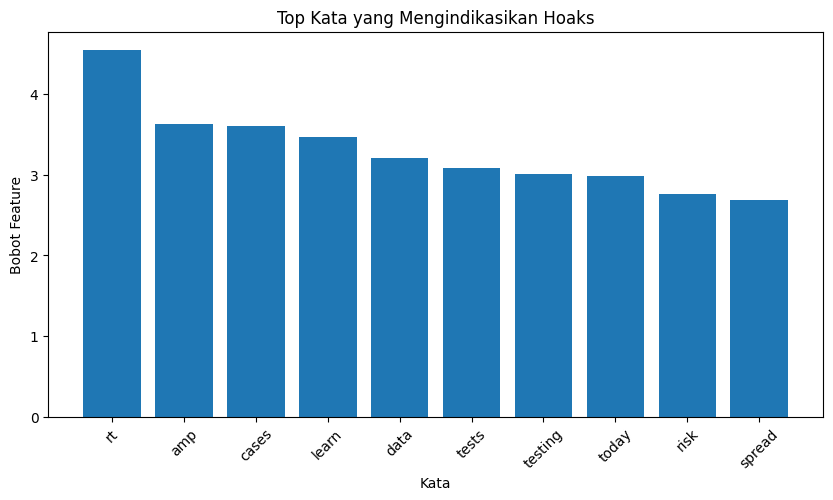

In [204]:
# =========================================================
# VISUALISASI TOP FITUR TF-IDF
# =========================================================

feature_names = tfidf.get_feature_names_out()

coef = model.coef_[0]

top_fake = coef.argsort()[-10:]

top_features = [feature_names[i] for i in reversed(top_fake)]

top_scores = [coef[i] for i in reversed(top_fake)]

plt.figure(figsize=(10,5))

plt.bar(
    top_features,
    top_scores
)

plt.title("Top Kata yang Mengindikasikan Hoaks")
plt.xlabel("Kata")
plt.ylabel("Bobot Feature")

plt.xticks(rotation=45)

plt.show()

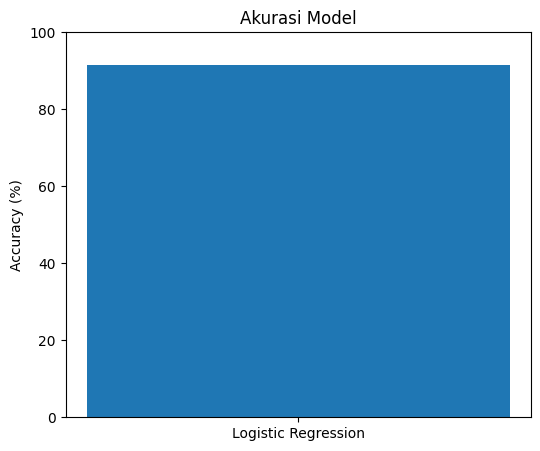

In [205]:
# =========================================================
# VISUALISASI AKURASI MODEL
# =========================================================

models = ["Logistic Regression"]

scores = [accuracy * 100]

plt.figure(figsize=(6,5))

plt.bar(
    models,
    scores
)

plt.title("Akurasi Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.show()

In [209]:
# simpan dataset hasil cleaning

test_df.to_csv("test_clean.csv", index=False)
print("Dataset berhasil disimpan: test_clean.csv")

train_df.to_csv("train_clean.csv", index=False)
print("Dataset berhasil disimpan: train_clean.csv")

val_df.to_csv("val_clean.csv", index=False)
print("Dataset berhasil disimpan: val_clean.csv")

english_df.to_csv("english_clean.csv", index=False)
print("Dataset berhasil disimpan: english_clean.csv")

ernie_df.to_csv("ernie_clean.csv", index=False)
print("Dataset berhasil disimpan: ernie_clean.csv")

Dataset berhasil disimpan: test_clean.csv
Dataset berhasil disimpan: train_clean.csv
Dataset berhasil disimpan: val_clean.csv
Dataset berhasil disimpan: english_clean.csv
Dataset berhasil disimpan: ernie_clean.csv
